In [1]:
#Creator : CARDOT-BUTZ Néo
#Version : 0.1
#Date of creation : (11/05/20260)


import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, exp, pi

# --- Constantes physiques et graphiques ----------------------------------------
TWO_PI: float = 2 * pi
H_BARRE: float = 6.63e-34 / TWO_PI  # Constante de Planck réduite [J.s]
M: float = 9.109e-31  # Masse d'un électron [kg]

COLORS_PLOT: list[str] = ["purple", "blue", "green", "yellow", "red"]
FIGURE_SIZE: tuple[int, int] = (8, 10)

# --- Constantes de la grille spatiale ----------------------------------------
x_debut = 0
x_fin = 10
nb_pts = 200


# --- Définition des Fonctions ----------------------------------------
def tracer_graphique(x: np.ndarray, psi: np.ndarray, t, a, k_0) -> None:
    """Trace les parties réelle, imaginaire et leur somme du paquet d'ondes."""
    wavelength = TWO_PI / k_0
    ylabel = f"a={a} m | k₀={k_0} m⁻¹ | λ={wavelength:.3g} m"

    components = [
        (psi.real, f"Partie réelle de Ψ(x, t={t})"),
        (psi.imag, f"Partie imaginaire de Ψ(x, t={t})"),
        (psi.real + psi.imag, f"Ψ(x, t={t})"),
    ]

    fig, axes = plt.subplots(3, 1, figsize=FIGURE_SIZE)
    fig.suptitle("Paquet d'ondes gaussien", fontsize=14, fontweight="bold")

    for ax, color, (data, title) in zip(axes, COLORS_PLOT, components):
        ax.plot(x, data, color=color)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(True)

    plt.tight_layout()
    plt.show()


def GaussWP(k_0: float, a: float, x: np.ndarray, t: float) -> np.ndarray:
    """Calcule les valeurs complexes de la fonction d'onde."""
    a_carre = a**2
    psi_0 = (
        sqrt(a)
        / (TWO_PI) ** (-3 / 4)
        * sqrt(pi / (a_carre / 4 + 1j * H_BARRE * t / (2 * M)))
    )
    u = (
        -x**2 + 1j * (a_carre * k_0 * x - (a_carre * k_0**2 * H_BARRE * t) / (2 * M))
    ) / (a_carre + 1j * (2 * H_BARRE * t) / (2 * M))
    return psi_0 * exp(u)

In [2]:
# Modifiez ces valeurs pour expérimenter :
k_0 = 5  # Vecteur d'onde central
a = 0.5 # Largeur du paquet
t = 0  # Instant t

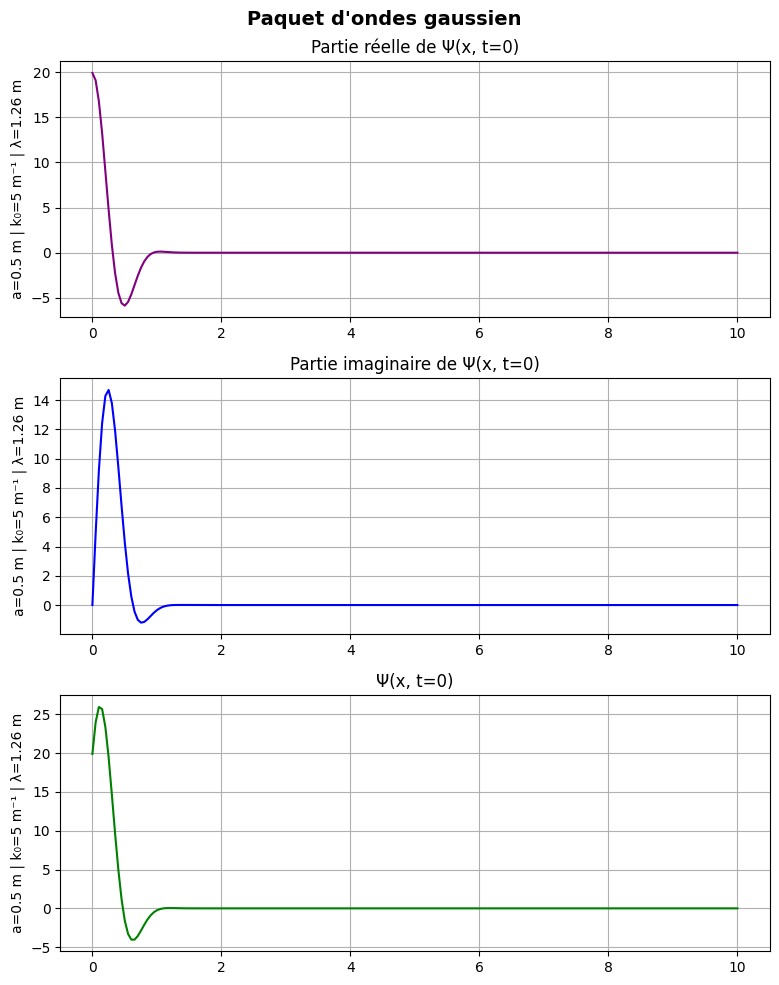

In [3]:
# 1. Génération de la grille de points
x = np.linspace(x_debut, x_fin, nb_pts)

# 2. Calcul de la fonction d'onde avec vos paramètres
waves = GaussWP(k_0, a, x, t)

# 3. Affichage
tracer_graphique(x, waves, t, a, k_0)